In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

Baris kode ini merupakan bagian untuk mengimpor library yang dibutuhkan. Library numpy diimpor dengan alias np dan digunakan untuk melakukan operasi matematis pada array multidimensi yang merepresentasikan piksel gambar. Library matplotlib.pyplot diimpor dengan alias plt dan digunakan untuk menampilkan gambar maupun grafik histogram secara visual. Library cv2 diimpor dengan alias cv dan digunakan khusus untuk membaca file gambar dari disk serta mengubahnya ke format grayscale.

In [2]:
citra1 = cv.imread('assets/potongan1.jpg')
citra2 = cv.imread('assets/potongan2.jpg')
citra3 = cv.imread('assets/potongan3.jpg')
citra4 = cv.imread('assets/potongan4.jpg')

Baris kode ini digunakan untuk membaca empat buah file gambar dari folder assets menggunakan fungsi cv.imread(). Setiap gambar disimpan ke dalam variabel citra1, citra2, citra3, dan citra4. Hasil dari fungsi imread() adalah array tiga dimensi yang merepresentasikan nilai piksel dalam format warna BGR (Blue, Green, Red) dengan nilai antara 0 hingga 255 untuk setiap channel warnanya.

Baris kode ini digunakan untuk menampilkan keempat gambar yang telah dimuat sebelumnya dalam satu kanvas menggunakan fungsi plt.subplot(2, 2, n) yang membagi kanvas menjadi grid 2 baris dan 2 kolom. Fungsi plt.imshow() digunakan untuk menampilkan gambar, plt.axis('off') untuk menyembunyikan sumbu koordinat agar tampilan lebih bersih, dan plt.title() untuk menambahkan judul pada masing-masing gambar.

Text(0.5, 1.0, 'potongan 4')

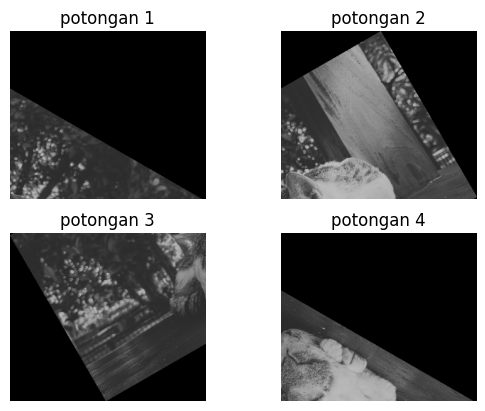

In [3]:
plt.subplot(2, 2, 1)
plt.imshow(citra1)
plt.axis('off')
plt.title('potongan 1')

plt.subplot(2, 2, 2)
plt.imshow(citra2)
plt.axis('off')
plt.title('potongan 2')

plt.subplot(2, 2, 3)
plt.imshow(citra3)
plt.axis('off')
plt.title('potongan 3')

plt.subplot(2, 2, 4)
plt.imshow(citra4)
plt.axis('off')
plt.title('potongan 4')


In [4]:
gray_a = cv.cvtColor(citra1, cv.COLOR_BGR2GRAY)
gray_b = cv.cvtColor(citra2, cv.COLOR_BGR2GRAY)
gray_c = cv.cvtColor(citra3, cv.COLOR_BGR2GRAY)
gray_d = cv.cvtColor(citra4, cv.COLOR_BGR2GRAY)


Baris kode ini digunakan untuk mengubah keempat gambar dari format warna BGR menjadi format grayscale menggunakan fungsi cv.cvtColor() dengan parameter cv.COLOR_BGR2GRAY. Proses konversi ini mengubah gambar yang semula memiliki 3 channel warna menjadi hanya 1 channel, di mana setiap piksel direpresentasikan dengan satu nilai antara 0 (hitam) hingga 255 (putih). Hasilnya disimpan ke variabel gray_a, gray_b, gray_c, dan gray_d yang akan digunakan untuk proses selanjutnya.

Baris kode ini menampilkan keempat gambar hasil konversi grayscale dalam satu kanvas menggunakan layout 2 baris dan 2 kolom. Parameter cmap="gray" pada fungsi plt.imshow() digunakan agar gambar grayscale ditampilkan dalam warna hitam putih yang sesuai. Tanpa parameter ini, matplotlib akan menampilkan gambar grayscale dengan peta warna default yang menghasilkan tampilan warna-warni yang tidak sesuai.

Text(0.5, 1.0, 'potongan 4')

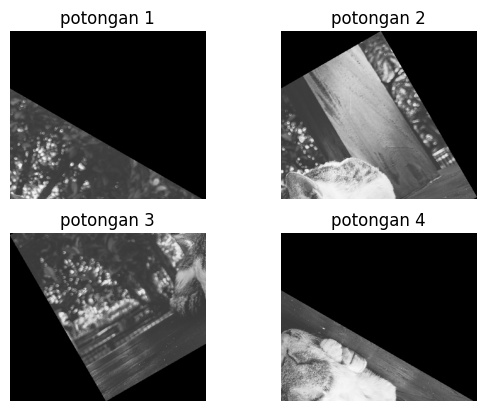

In [5]:
plt.subplot(2, 2, 1)
plt.imshow(gray_a, cmap = "gray")
plt.axis('off')
plt.title('potongan 1')

plt.subplot(2, 2, 2)
plt.imshow(gray_b, cmap = "gray")
plt.axis('off')
plt.title('potongan 2')

plt.subplot(2, 2, 3)
plt.imshow(gray_c, cmap = "gray")
plt.axis('off')
plt.title('potongan 3')

plt.subplot(2, 2, 4)
plt.imshow(gray_d, cmap = "gray")
plt.axis('off')
plt.title('potongan 4')


In [6]:
def flipping(image, mode='x'):
    h, w = image.shape
    hasil = np.zeros((h, w), dtype = image.dtype)
    for i in range (h):
        for j in range (w):
            if mode == 'x':
                hasil[i, j] = image[h-1-i, j]
            elif mode == 'y':
                hasil[i, j] = image[i, w-1-j]
    return hasil

Baris kode ini mendefinisikan fungsi flipping() yang digunakan untuk mencerminkan gambar secara horizontal maupun vertikal. Fungsi ini menerima dua parameter yaitu image sebagai gambar masukan dan mode sebagai arah pencerminan. Jika mode bernilai 'x', gambar akan dicerminkan secara vertikal dengan menukar posisi baris, baris pertama menjadi baris terakhir dan sebaliknya  menggunakan rumus hasil[i,j] = image[h-1-i, j]. Jika mode bernilai 'y', gambar akan dicerminkan secara horizontal dengan menukar posisi kolom menggunakan rumus hasil[i,j] = image[i, w-1-j]. Proses ini dilakukan dengan dua buah loop yang mengunjungi setiap piksel gambar satu per satu.

In [7]:
flip_citra1 = flipping(gray_a, 'y')
flip_citra4 = flipping(gray_d, 'x')

Baris kode ini menerapkan fungsi flipping() pada gambar yang membutuhkan pencerminan. Gambar pertama (gray_a) dicerminkan secara horizontal dengan mode 'y' dan hasilnya disimpan ke variabel flip_citra1. Gambar keempat (gray_d) dicerminkan secara vertikal dengan mode 'x' dan hasilnya disimpan ke variabel flip_citra4. Sementara gambar kedua (gray_b) dan ketiga (gray_c) tidak mengalami pencerminan karena orientasinya sudah benar.

Baris kode ini menampilkan keempat gambar setelah proses flipping dalam satu kanvas dengan layout 2 baris dan 2 kolom. Posisi pertama menampilkan flip_citra1 yang sudah dicerminkan horizontal, posisi kedua menampilkan gray_b yang tidak diubah, posisi ketiga menampilkan gray_c yang tidak diubah, dan posisi keempat menampilkan flip_citra4 yang sudah dicerminkan vertikal. Fungsi plt.tight_layout() digunakan agar jarak antar gambar tersusun rapi dan tidak saling tumpang tindih.

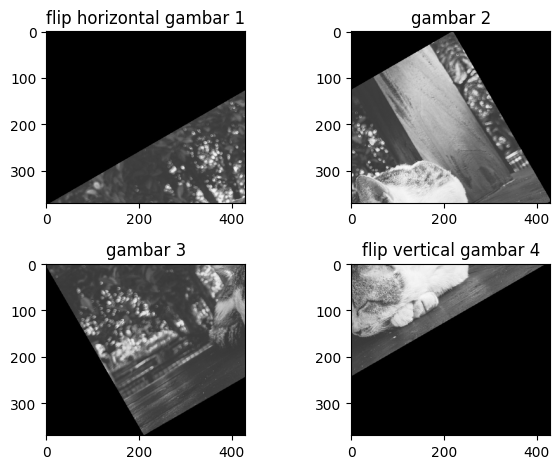

In [8]:
plt.subplot(2, 2, 1)
plt.imshow(flip_citra1, cmap = "gray")
plt.title('flip horizontal gambar 1')

plt.subplot(2, 2, 2)
plt.imshow(gray_b, cmap = "gray")
plt.title('gambar 2')

plt.subplot(2, 2, 3)
plt.imshow(gray_c, cmap = "gray")
plt.title('gambar 3')

plt.subplot(2, 2, 4)
plt.imshow(flip_citra4, cmap = "gray")
plt.title('flip vertical gambar 4')
plt.tight_layout()
plt.show()

In [9]:
def merge_horizontal(citra_1, citra_2): 
    c1, c2 = np.array(citra_1), np.array(citra_2) 
    tinggi = max(c1.shape[0], c2.shape[0]) 
    lebar = c1.shape[1] + c2.shape[1] 
    hasil = np.zeros((tinggi, lebar), dtype=c1.dtype) 
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1 
    hasil[0:c2.shape[0], c1.shape[1]:] = c2 
    return hasil 

def merge_vertikal(citra_1, citra_2): 
    c1, c2 = np.array(citra_1), np.array(citra_2) 
    tinggi = c1.shape[0] + c2.shape[0] 
    lebar = max(c1.shape[1], c2.shape[1]) 
    hasil = np.zeros((tinggi, lebar), dtype=c1.dtype) 
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1 
    hasil[c1.shape[0]:, 0:c2.shape[1]] = c2 
    return hasil 


Baris kode ini mendefinisikan dua fungsi penggabungan gambar. Fungsi merge_horizontal() digunakan untuk menggabungkan dua gambar secara berdampingan kiri-kanan, di mana lebar kanvas hasil merupakan penjumlahan lebar kedua gambar dan tinggi kanvas mengambil nilai terbesar dari keduanya. Gambar pertama ditempatkan di sisi kiri dan gambar kedua di sisi kanan kanvas. Fungsi merge_vertikal() digunakan untuk menggabungkan dua gambar secara bertumpuk atas-bawah, di mana tinggi kanvas hasil merupakan penjumlahan tinggi kedua gambar dan lebar kanvas mengambil nilai terbesar dari keduanya. Gambar pertama ditempatkan di bagian atas dan gambar kedua di bagian bawah kanvas.

In [10]:
mergeAC = merge_vertikal(flip_citra1, gray_c)
mergeBD = merge_vertikal(gray_b, flip_citra4)
mergeABCD = merge_horizontal(mergeAC, mergeBD)

Baris kode ini menggabungkan keempat potongan gambar menjadi satu citra utuh. Pertama, flip_citra1 dan gray_c digabung secara vertikal (atas-bawah) menghasilkan mergeAC yang merupakan kolom kiri. Kemudian gray_b dan flip_citra4 digabung secara vertikal menghasilkan mergeBD yang merupakan kolom kanan. Terakhir, mergeAC dan mergeBD digabung secara horizontal (kiri-kanan) menghasilkan mergeABCD yang merupakan citra utuh hasil penggabungan keempat potongan.

Baris kode ini menampilkan citra hasil penggabungan keempat potongan (mergeABCD) dalam satu figure berukuran 6x5 inci menggunakan mode grayscale. Hasilnya adalah gambar utuh yang merupakan rekonstruksi dari keempat potongan yang telah melalui proses flipping dan penggabungan.

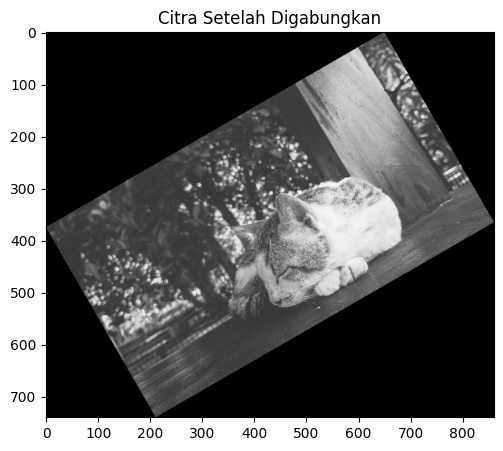

In [11]:
plt.figure(figsize=(6, 5))
plt.imshow(mergeABCD, cmap = 'gray')
plt.title('Citra Setelah Digabungkan')
plt.show()

In [12]:
citra_5 = cv.imread('assets/inv.jpg')
citra5 = cv.cvtColor(citra_5, cv.COLOR_BGR2GRAY)

Baris kode ini membaca file gambar referensi bernama inv.jpg dari folder assets menggunakan cv.imread() dan langsung mengubahnya ke format grayscale menggunakan cv.cvtColor(). Gambar ini adalah citra biner yang hanya memiliki dua nilai piksel yaitu 0 (hitam) dan 255 (putih), yang akan digunakan sebagai mask untuk mengisolasi bagian kucing dari citra gabungan.

Baris kode ini menampilkan citra referensi (citra5) yang telah dibaca sebelumnya dalam format grayscale. Citra ini merupakan citra biner berbentuk siluet kucing yang akan digunakan sebagai topeng (mask) pada proses selanjutnya.

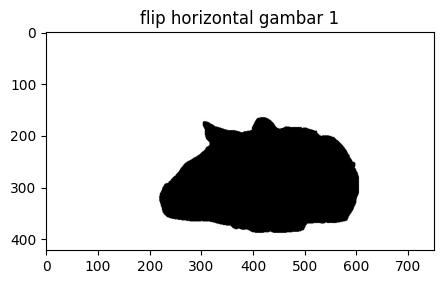

In [13]:
plt.figure(figsize=(5, 5))
plt.imshow(citra5, cmap='gray')
plt.title('flip horizontal gambar 1')
plt.show()

In [14]:
def rotasi_sudut(image, derajat):
    h, w = image.shape
    
    rad = derajat * np.pi / 180
    cos_a = np.cos(rad)
    sin_a = np.sin(rad)

    cx = w / 2
    cy = h / 2

    rx0 = cos_a * (0 - cx) - sin_a * (0 - cy) + cx
    ry0 = sin_a * (0 - cx) + cos_a * (0 - cy) + cy

    rx1 = cos_a * (w - cx) - sin_a * (0 - cy) + cx
    ry1 = sin_a * (w - cx) + cos_a * (0 - cy) + cy

    rx2 = cos_a * (0 - cx) - sin_a * (h - cy) + cx
    ry2 = sin_a * (0 - cx) + cos_a * (h - cy) + cy

    rx3 = cos_a * (w - cx) - sin_a * (h - cy) + cx
    ry3 = sin_a * (w - cx) + cos_a * (h - cy) + cy

    new_w = int(max([rx0, rx1, rx2, rx3]) - min([rx0, rx1, rx2, rx3])) + 1
    new_h = int(max([ry0, ry1, ry2, ry3]) - min([ry0, ry1, ry2, ry3])) + 1

    ox = (new_w - w) / 2
    oy = (new_h - h) / 2

    hasil = np.zeros((new_h, new_w), dtype=image.dtype)

    for i in range(new_h):
        for j in range(new_w):
            x0 = j - ox - cx
            y0 = i - oy - cy

            xr = int(cos_a * x0 + sin_a * y0 + cx)
            yr = int(-sin_a * x0 + cos_a * y0 + cy)

            if 0 <= xr < w and 0 <= yr < h:
                hasil[i, j] = image[yr, xr]

    return hasil

Baris kode ini mendefinisikan fungsi rotasi_sudut() yang mampu memutar gambar pada berbagai sudut. Fungsi ini bekerja dengan mengkonversi derajat ke radian, kemudian menghitung nilai cosinus dan sinus dari sudut tersebut. Untuk menentukan ukuran kanvas baru agar gambar tidak terpotong setelah dirotasi, fungsi ini menghitung koordinat keempat sudut gambar asli setelah dirotasi lalu mencari nilai minimum dan maksimumnya. Proses utama rotasi menggunakan teknik inverse mapping  untuk setiap piksel di kanvas baru, dicari koordinat asalnya di gambar lama menggunakan rumus rotasi invers, sehingga tidak ada piksel yang terlewat.

Baris kode ini menerapkan fungsi rotasi_sudut() pada citra referensi (citra5) dengan sudut -30 derajat (berlawanan arah jarum jam). Hasil rotasi disimpan ke variabel rotasi_min30 dan ditampilkan dalam figure berukuran 6x6 inci. Proses ini dilakukan agar posisi citra referensi selaras dengan orientasi citra utama yang telah digabungkan sebelumnya.

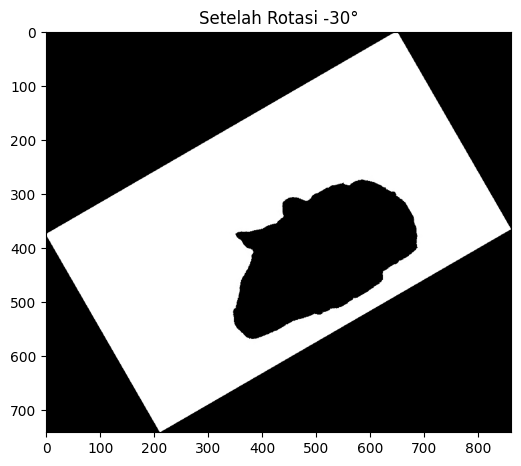

In [15]:
rotasi_min30 = rotasi_sudut(citra5, -30)

plt.figure(figsize=(6, 6))
plt.imshow(rotasi_min30, cmap='gray')
plt.title('Setelah Rotasi -30°')
plt.show()

Baris kode ini melakukan dua proses sekaligus. Pertama adalah proses masking, di mana citra biner rotasi_min30 digunakan sebagai topeng untuk mengisolasi bagian kucing dari mergeABCD. Ukuran kedua citra disamakan terlebih dahulu dengan mengambil dimensi terkecil dari keduanya. Setiap piksel yang bernilai 0 (hitam) pada rotasi_min30 akan mengambil nilai piksel dari mergeABCD, sedangkan piksel yang bernilai selain 0 akan diisi dengan 0 (hitam). Hasil masking kemudian ditampilkan berdampingan dengan citra gabungan dan citra biner untuk perbandingan. Kedua, hasil masking dirotasi kembali sebesar +30 derajat menggunakan rotasi_sudut() agar orientasi citra kembali mendekati kondisi semula sebelum dirotasi -30°.

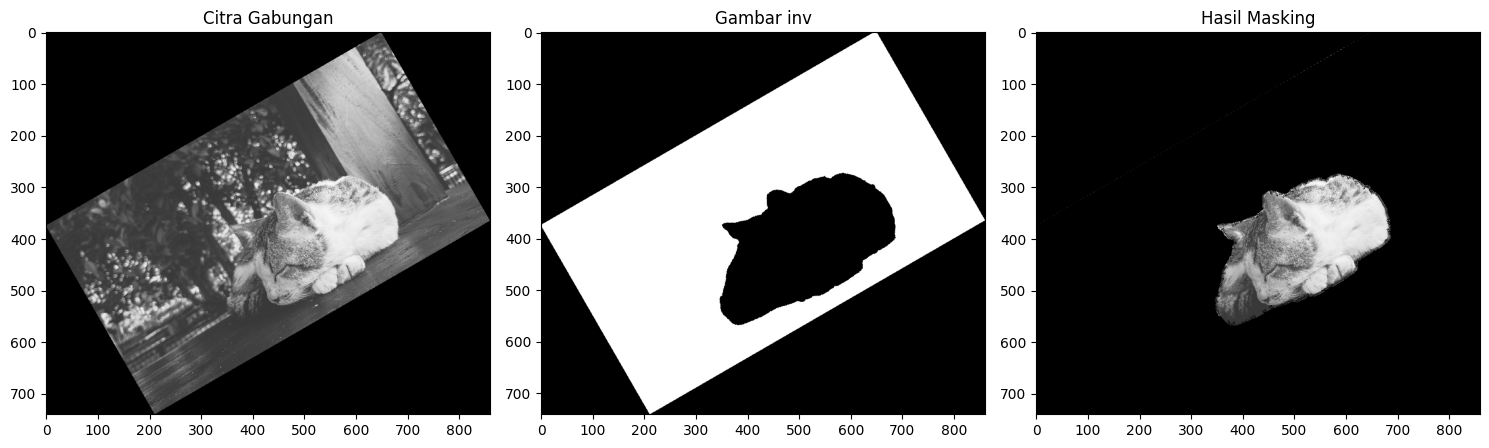

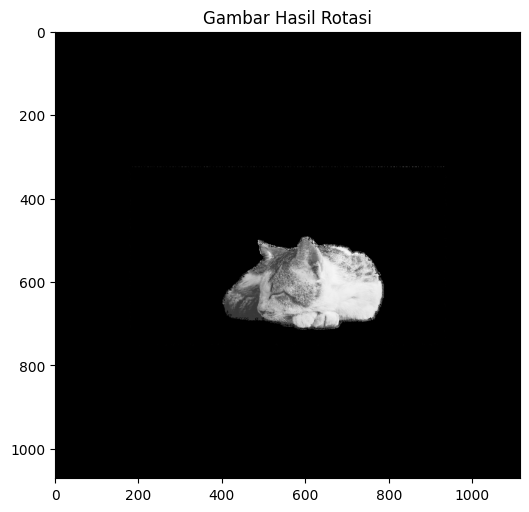

In [16]:
h1, w1 = rotasi_min30.shape
h2, w2 = mergeABCD.shape

h_min = h1 if h1 < h2 else h2
w_min = w1 if w1 < w2 else w2

hasil_mask = np.zeros((h_min, w_min), dtype=np.uint8)
for i in range(h_min):
    for j in range(w_min):
        if rotasi_min30[i, j] == 0:      
            hasil_mask[i, j] = mergeABCD[i, j]
        else:                               
            hasil_mask[i, j] = 0

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(mergeABCD, cmap='gray')
plt.title('Citra Gabungan')

plt.subplot(1, 3, 2)
plt.imshow(rotasi_min30, cmap='gray')
plt.title('Gambar inv')

plt.subplot(1, 3, 3)
plt.imshow(hasil_mask, cmap='gray')
plt.title('Hasil Masking')

plt.tight_layout()
plt.show()

rotasi_plus30 = rotasi_sudut(hasil_mask, 30)

plt.figure(figsize=(6, 6))
plt.imshow(rotasi_plus30, cmap='gray')
plt.title('Gambar Hasil Rotasi')
plt.show()

In [17]:
def dilatasi(image, p1=0, p2=0, p3=0, p4=0):
    h, w = image.shape
   
    dilated = np.zeros((h * 2, w * 2)).astype(int)
    for y in range(h * 2):
        for x in range(w * 2):
            dilated[y][x] = image[int(y / 2)][int(x / 2)]
    
    sy, ey = max(0, p1), min(h * 2, h * 2 - p2)
    sx, ex = max(0, p3), min(w * 2, w * 2 - p4)
    return dilated[sy:ey, sx:ex]

Baris kode ini mendefinisikan fungsi dilatasi() yang digunakan untuk memperbesar gambar sebesar 2 kali lipat. Cara kerjanya adalah dengan membuat kanvas baru berukuran 2 kali tinggi dan 2 kali lebar gambar asli, kemudian setiap piksel di kanvas baru diisi dengan nilai piksel dari gambar asli di posisi setengahnya sehingga setiap 1 piksel asli menjadi 4 piksel (2x2) di gambar hasil. Fungsi ini juga menerima parameter p1, p2, p3, p4 yang digunakan untuk memotong tepi gambar dari arah atas, bawah, kiri, dan kanan setelah proses pembesaran.

In [18]:
dilatasi1 = dilatasi(rotasi_plus30, 650, 650, 650, 650)

Baris kode ini menerapkan fungsi dilatasi() pada rotasi_plus30 dengan nilai crop 650 piksel di setiap sisi. Proses ini memperbesar gambar 2 kali lipat sekaligus memotong tepi-tepinya agar hanya bagian kucing yang relevan yang tersisa dan ukuran gambar menjadi lebih proporsional.

Baris kode ini menampilkan hasil dilatasi (dilatasi1) menggunakan plt.subplot() dalam mode grayscale untuk memverifikasi hasil pembesaran citra.

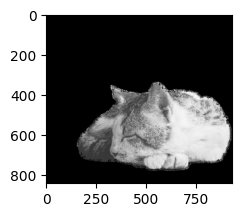

In [19]:
plt.subplot(2, 2, 1)
plt.imshow(dilatasi1, cmap = "gray")

Baris kode ini melakukan pembagian setiap nilai piksel dengan angka 2 menggunakan operator pembagian bulat (//). Pertama, dilatasi1 dikonversi ke tipe data uint8 dan disimpan ke citra_dilatasi. Kemudian dibuat kanvas kosong citra_bagi2 dengan ukuran yang sama, dan setiap piksel diisi dengan nilai piksel citra_dilatasi dibagi 2. Proses ini bertujuan untuk menstabilkan intensitas citra yang terlalu besar akibat proses-proses sebelumnya, sehingga range nilai piksel yang semula bisa mencapai 255 menjadi maksimal 127. Range yang lebih sempit ini akan membuat proses normalisasi selanjutnya terlihat lebih jelas efeknya.

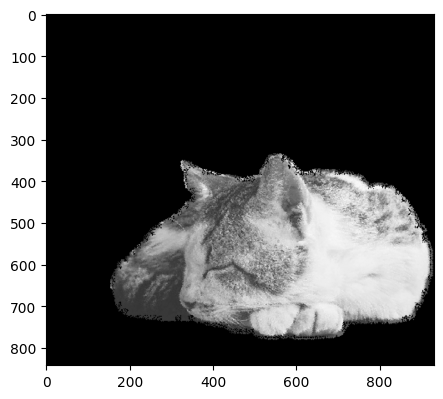

In [20]:
citra_dilatasi = np.array(dilatasi1, dtype=np.uint8)

tinggi, lebar = citra_dilatasi.shape

citra_bagi2 = np.zeros((tinggi, lebar), dtype=np.uint8)
for i in range(tinggi):
    for j in range(lebar):
        citra_bagi2[i][j] = citra_dilatasi[i][j] // 2

plt.figure(figsize=(5, 5))
plt.imshow(citra_bagi2, cmap="gray")
plt.show()

In [21]:
def normalisasi(citra):
    min_val = int(citra[0,0])
    max_val = int(citra[0,0])
    for i in range(citra.shape[0]):
        for j in range(citra.shape[1]):
            if citra[i,j] < min_val: min_val = int(citra[i,j])
            if citra[i,j] > max_val: max_val = int(citra[i,j])
    
    hasil = np.zeros(citra.shape, dtype=np.uint8)
    for i in range(citra.shape[0]):
        for j in range(citra.shape[1]):
            hasil[i,j] = int((int(citra[i,j]) - min_val) / (max_val - min_val) * 255)
    return hasil

def hitung_histogram(citra):
    hist = np.zeros(256, dtype=int)
    for i in range(citra.shape[0]):
        for j in range(citra.shape[1]):
            hist[citra[i, j]] += 1
    return hist


Baris kode ini mendefinisikan dua fungsi. Fungsi normalisasi() bekerja dengan mencari nilai piksel terkecil (min_val) dan terbesar (max_val) dari seluruh piksel citra melalui loop, kemudian meregangkan semua nilai piksel ke rentang 0-255 menggunakan rumus: nilai_baru = (nilai_lama - min) / (max - min) * 255. Fungsi hitung_histogram() bekerja dengan menyiapkan array berisi 256 slot (untuk nilai 0-255), kemudian menghitung berapa banyak piksel yang memiliki setiap nilai intensitas melalui loop seluruh piksel citra.

Baris kode ini menerapkan normalisasi pada citra_bagi2 dan menampilkan histogram sebelum dan sesudah normalisasi.

Analisis histogram: Sebelum normalisasi, histogram citra_bagi2 menunjukkan distribusi yang sangat sempit dan menumpuk di sekitar nilai rendah (0-127), hal ini terjadi karena proses pembagian piksel dengan 2 pada tahap sebelumnya menyebabkan seluruh nilai piksel tersebar di setengah range. Terdapat tumpukan yang sangat tinggi di nilai 0 yang berasal dari piksel latar belakang hitam, sementara piksel yang merepresentasikan objek kucing tersebar tipis di nilai 1-127. Setelah normalisasi dilakukan, histogram menunjukkan perubahan yang signifikan di mana distribusi piksel kini tersebar lebih luas hingga mendekati nilai 255. Proses normalisasi berhasil meregangkan range intensitas dari yang semula hanya 0-127 menjadi 0-255, sehingga kontras citra meningkat dan detail-detail pada gambar kucing yang sebelumnya sulit terlihat kini menjadi lebih jelas dan terang. Namun tumpukan di nilai 0 tetap ada karena piksel latar belakang hitam yang jumlahnya sangat banyak tidak berubah posisinya setelah normalisasi.

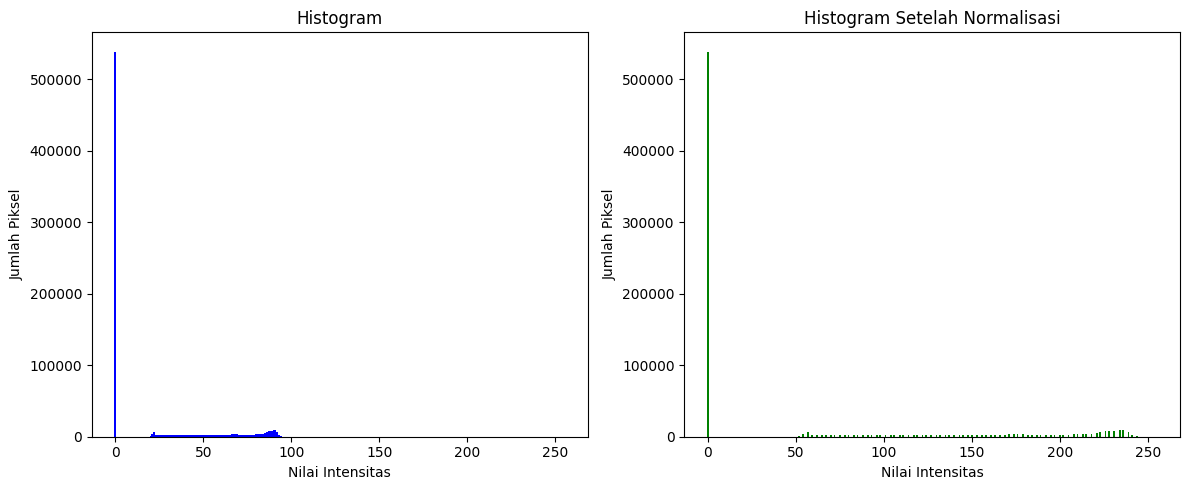

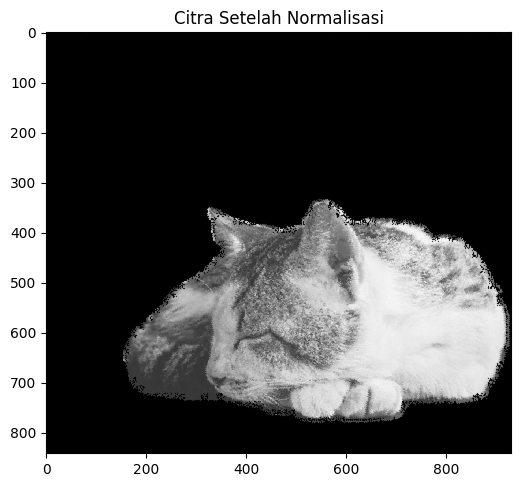

In [22]:
norm = normalisasi(citra_bagi2)

hist_sebelum = hitung_histogram(citra_bagi2)
hist_sesudah = hitung_histogram(norm)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(range(256), hist_sebelum, width=1, color='blue')
plt.title('Histogram')
plt.xlabel('Nilai Intensitas')
plt.ylabel('Jumlah Piksel')

plt.subplot(1, 2, 2)
plt.bar(range(256), hist_sesudah, width=1, color='green')
plt.title('Histogram Setelah Normalisasi')
plt.xlabel('Nilai Intensitas')
plt.ylabel('Jumlah Piksel')

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.imshow(norm, cmap='gray')
plt.title('Citra Setelah Normalisasi')
plt.show()

In [23]:
kernel = [
    [-1/10, -1/10, -1/10, -1/10],
    [-1/10,  4/10,  4/10, -1/10],
    [-1/10,  4/10,  4/10, -1/10],
    [-1/10, -1/10, -1/10, -1/10]
]

def zero_padding(citra, pad):
    h, w = citra.shape
    hasil = np.zeros((h + 2*pad, w + 2*pad), dtype=citra.dtype)
    hasil[pad:pad+h, pad:pad+w] = citra
    return hasil

def konvolusi(citra, kernel):
    k_h = len(kernel)
    k_w = len(kernel[0])
    pad = k_h // 2
    
    citra_pad = zero_padding(citra, pad)
    h, w = citra.shape
    hasil = np.zeros((h, w), dtype=np.float64)
    
    for i in range(h):
        for j in range(w):
            total = 0.0
            for ki in range(k_h):
                for kj in range(k_w):
                    total += citra_pad[i+ki, j+kj] * kernel[ki][kj]
            hasil[i, j] = total
    
    return hasil

def clipping(citra):
    hasil = np.zeros(citra.shape, dtype=np.uint8)
    for i in range(citra.shape[0]):
        for j in range(citra.shape[1]):
            val = citra[i, j]
            hasil[i, j] = 255 if val > 255 else (0 if val < 0 else int(val))
    return hasil

Baris kode ini mendefinisikan kernel dan tiga fungsi pemrosesan citra. Kernel berbentuk matriks 4x4 dengan nilai -1/10 di tepi dan 4/10 di bagian tengah, yang bersifat sharpening untuk mempertajam tepi dan detail gambar. Fungsi zero_padding() menambahkan border hitam (nilai 0) di sekeliling gambar sebesar pad piksel di setiap sisi, tujuannya agar piksel di tepi gambar tetap bisa diproses konvolusi tanpa kehilangan informasi. Fungsi konvolusi() menggeser kernel ke setiap posisi piksel gambar, mengalikan nilai piksel di area 4x4 sekitarnya dengan nilai kernel yang bersesuaian, lalu menjumlahkan hasilnya menjadi nilai piksel baru. Fungsi clipping() memastikan semua nilai piksel hasil konvolusi berada dalam range valid 0-255, di mana nilai di atas 255 dipotong menjadi 255 dan nilai negatif dipaksa menjadi 0.

Baris kode ini menerapkan fungsi konvolusi() pada citra hasil normalisasi (norm) menggunakan kernel yang telah didefinisikan, kemudian hasilnya diproses dengan clipping() agar nilai piksel kembali valid di range 0-255. Hasil akhir disimpan ke citra_clip dan ditampilkan dalam figure berukuran 6x6 inci. Gambar hasil konvolusi akan terlihat lebih tajam pada bagian tepi dan detail dibandingkan sebelumnya karena pengaruh kernel sharpening.

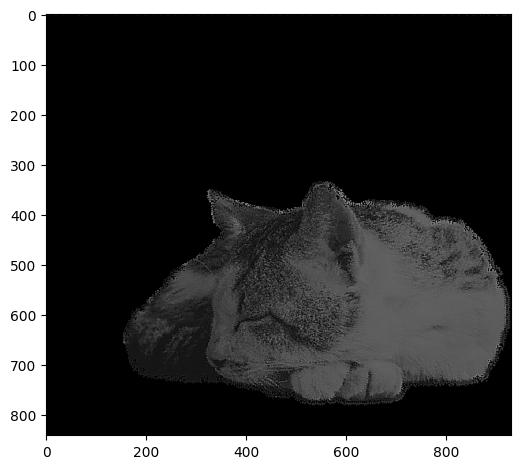

In [24]:
citra_conv = konvolusi(norm, kernel)
citra_clip = clipping(citra_conv)

plt.figure(figsize=(6, 6))
plt.imshow(citra_clip, cmap='gray')
plt.show()

Baris kode ini menampilkan histogram dari citra hasil akhir (citra_clip) setelah melalui seluruh proses pengolahan. Histogram ini menunjukkan distribusi intensitas piksel setelah konvolusi dan clipping diterapkan. Dibandingkan dengan histogram sebelumnya, distribusi piksel pada histogram akhir cenderung bergeser karena pengaruh kernel sharpening yang memperkuat perbedaan antar piksel, sehingga piksel di area tepi objek mengalami peningkatan nilai sementara area yang homogen relatif tidak banyak berubah.

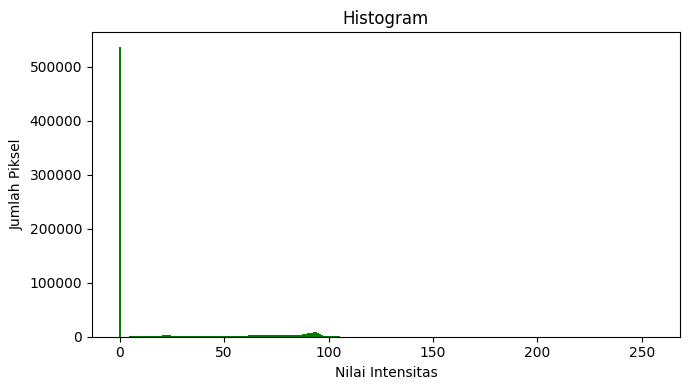

In [25]:
hist_akhir = hitung_histogram(citra_clip)
plt.figure(figsize=(7, 4))
plt.bar(range(256), hist_akhir, width=1, color='green')
plt.title('Histogram')
plt.xlabel('Nilai Intensitas')
plt.ylabel('Jumlah Piksel')
plt.tight_layout()
plt.show()

Analisa Hasil Akhir: Pada jurnal ini memproses empat potongan citra kucing melalui serangkaian tahapan yang saling berkaitan. Keempat potongan pertama-tama dibaca dan dikonversi ke grayscale agar nilai piksel seragam dalam 1 channel, kemudian potongan pertama dicerminkan horizontal dan potongan keempat dicerminkan vertikal, lalu keempatnya digabungkan menjadi satu citra utuh. Citra dirotasi -30°, untuk setiap piksel di kanvas baru dicari koordinat asalnya di gambar lama, sehingga tidak ada piksel yang terlewat dan gambar tidak terpotong. Citra yang telah dirotasi, dirotasi kembali +30°, diperbesar 2x melalui dilatasi, dan dipotong tepinya agar hanya area kucing yang tersisa. Intensitas citra kemudian dibagi 2 untuk menstabilkan nilai piksel yang terlalu tinggi, lalu dinormalisasi menggunakan rumus min-max agar sebaran intensitas meluas ke rentang 0–255 sehingga kontras meningkat dan detail lebih terlihat. Sebelum konvolusi, diterapkan zero padding yaitu menambahkan border hitam di sekeliling citra agar piksel di tepi tetap bisa diproses oleh kernel tanpa kehilangan informasi. Konvolusi menggunakan kernel 4x4 kemudian diterapkan untuk mempertajam tepi dan detail objek, dan hasilnya diproses dengan clipping untuk memastikan nilai piksel yang melebihi 255 atau kurang dari 0 dikembalikan ke range yang valid.